In [1]:
import os, pickle
import matplotlib.pyplot as plt
import matplotlib as mpl
from py_util_dx.py_utils import setProjectPath
from scipy.stats import ttest_ind, ttest_1samp
from evaluations import *
import seaborn as sns 
import numpy as np
import matplotlib.pyplot as plt
import Functional_Fusion.atlas_map as am
from visualizations import flatmap_real_vals, plot_flatmap_labels
from nitools.cifti import surf_from_cifti
from py_util_dx.data_utils import get_roi_vtx_from_fs32k
from Functional_Fusion.reliability import flat2ndarray
from scipy.spatial.distance import pdist

In [2]:
mpl.rcParams['font.family'] = 'helvetica'   # Global font family
mpl.rcParams['font.size'] = 12              # Global font size 
full_width = 8.5
half_width = full_width/2

In [3]:
projectPath, mainResultsPath = setProjectPath()
dataset_name = 'MDTB' # or Demand
surface_helpers_dir = os.path.join(projectPath, 'surface_helpers')
resultsPath = os.path.join(mainResultsPath, '11_example_indiv_MD_regions', f'{dataset_name}')
if not os.path.exists(resultsPath):
    os.makedirs(resultsPath)

In [4]:
atlas_str = 'fs32k'
atlas, ainf = am.get_atlas(atlas_str)

In [5]:
# example_subjIs = np.arange(24)
example_subjIs = [4]
n_example_subjects = len(example_subjIs)

In [6]:
PKL_data = os.path.join(projectPath, 'data', f'{dataset_name}_CondHalf_all.pkl')
with open(PKL_data, 'rb') as pf:
    original_data = pickle.load(pf)
    X_individuals = original_data['X_individuals']
    info_individuals = original_data['info_individuals']
    dataset_obj_individuals = original_data['dataset_obj_individuals']

part_vec = list(info_individuals['half'])
cond_vec = list(info_individuals[dataset_obj_individuals.cond_ind])

# fill nans with 0
X_individuals[np.isnan(X_individuals)] = 0

(24, 122, 59518)

In [7]:
## whole cortex
# data = flat2ndarray(X_individuals, part_vec, cond_vec)

In [15]:
# mean response pattern across conditions 
# mean_response_pattern = np.mean(data, axis=2) 
mean_response_pattern = np.sum(X_individuals, axis=1) 

In [16]:
mean_response_pattern[4].min(), mean_response_pattern[4].max() 

(np.float64(-1.9317880628477724e-14), np.float64(8.770761894538737e-15))

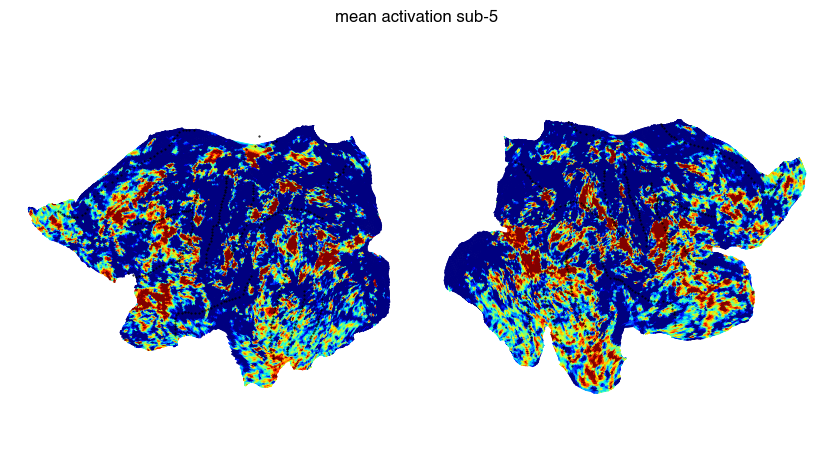

In [20]:
for subjI in example_subjIs:
    plt.figure().set_figwidth(full_width) 
    plt.subplot(1, 2, 1)
    flatmap_real_vals(mean_response_pattern[subjI], hemi='L', cscale=[-1e-15, 1e-15], cmap='jet') 
    plt.subplot(1, 2, 2)
    flatmap_real_vals(mean_response_pattern[subjI], hemi='R', cscale=[-1e-15, 1e-15], cmap='jet', colorbar=False)  
    plt.suptitle(f'mean activation sub-{subjI+1}', fontsize=12)
    plt.tight_layout()

    JPG_fig = os.path.join(resultsPath, f'mean_activation_sub{subjI+1}.jpg')
    plt.savefig(JPG_fig, format='jpg', dpi=500)

In [11]:
# for subjI in example_subjIs:
#     plt.figure().set_figwidth(full_width) 
#     plt.subplot(1, 2, 1)
#     flatmap_real_vals(mean_response_pattern[subjI, 0], hemi='L', cscale=[-0.01, 0.01], cmap='jet') 
#     plt.subplot(1, 2, 2)
#     flatmap_real_vals(mean_response_pattern[subjI, 0], hemi='R', cscale=[-0.01, 0.01], cmap='jet', colorbar=False)  
#     plt.suptitle(f'mean activation sub-{subjI+1}', fontsize=12)
#     plt.tight_layout()

#     JPG_fig = os.path.join(resultsPath, f'mean_activation_sub{subjI+1}.jpg')
#     plt.savefig(JPG_fig, format='jpg', dpi=500)